In [2]:
import json
import pathlib
import sys

sys.path.insert(0, "../Code")

In [2]:
MERGED_DIR = pathlib.Path("./Graphs_data_merged")

def load_instance_json(path):
    with open(path) as f:
        return json.load(f)

json_files = sorted(MERGED_DIR.glob("inst_*.json"))
print("Found %d instances" % len(json_files))

Found 159 instances


In [8]:
inst = load_instance_json(json_files[0])
print(inst.keys())

dict_keys(['extra_params', 'graph', 'heuristic', 'gurobi'])


In [13]:
print("extra_params")
print(inst["extra_params"])

print("\ngraph keys")
print(inst["graph"].keys())

print("\nheuristic keys")
print(inst["heuristic"].keys())

print("\ngurobi keys")
print(inst["gurobi"].keys())

extra_params
{'n': 12, 'm': 0, 'shape': 'square', 'integer_size': True, 'size_min': 2, 'size_max': 8, 'grid_size': 50, 'time_heuristic_s': 0.013, 'time_gurobi_s': 3.5039}

graph keys
dict_keys(['grid_size', 'neighborhoods', 'edges'])

heuristic keys
dict_keys(['positions', 'mst', 'cost', 'original_cost', 'k'])

gurobi keys
dict_keys(['positions', 'mst', 'cost', 'stats', 'log'])


In [16]:
print("first neighborhood")
print(inst["graph"]["neighborhoods"][0])

print("\nfirst gurobi mst edge")
print(inst["gurobi"]["mst"][0])

first neighborhood
{'type': 'square', 'cx': 23, 'cy': 7, 'side': 5}

first gurobi mst edge
[0, 5, 9.82344135219425]


# Edge Scorer for the MSTN Problem

## Context

The **Minimum Spanning Tree with Neighborhoods (MSTN)** problem asks:
given $n$ convex neighborhoods in the plane, choose one representative point per
neighborhood and connect them by a spanning tree of minimum total Euclidean length.

This is NP-hard in general, and exact solvers (Gurobi MINLP) can take 30+ minutes
per instance even for $n = 12$ neighborhoods.

The goal of this notebook is to train an **edge scorer**: a classifier that, given
a new instance, predicts for each candidate edge $(i, j)$ the probability that it
belongs to the optimal (or near-optimal) spanning tree.

At inference time, the scorer is used to **prune the candidate edge set** before
running the heuristic or the exact solver, reducing the graph from
$\frac{n(n-1)}{2}$ candidates down to $3(n-1)$ while preserving 98.7% of
optimal trees on our test set.

---

## Dataset

We generated **159 instances** of random square-neighborhood MSTN problems using
Gurobi with a 30-minute time limit. Each instance was solved to near-optimality
(average MIP gap ≈ 3–4%), giving us a reference tree of $n - 1$ edges per instance.

Each instance is stored as a JSON file containing:
- `graph`: neighborhood geometry (center, side length) and complete graph edges,
- `heuristic`: the solution found by our alternating heuristic,
- `gurobi`: the near-optimal solution found by Gurobi (positions, MST, cost, stats),
- `extra_params`: generation parameters (n, grid size, seed, etc.).

---

## Pipeline

### Step 1 — Load instances
Read all 159 JSON files from the merged data directory.

### Step 2 — Build the edge dataset
For each instance and each candidate edge $(i, j)$:
- **Label**: 1 if the edge appears in the Gurobi solution tree, 0 otherwise.
- **Features**: geometric properties derived purely from the neighborhood geometry
  (no solver information), so the scorer can be applied to new unseen instances.

All features are **normalized within each instance** so that the scorer generalizes
across different instance sizes. A model trained on $n \leq 15$ can therefore be
applied directly to instances with $n = 100$ or more.

Features used per edge $(i, j)$:

| Feature | Description |
|---|---|
| `dist_norm` | Center distance $d_{ij}$ divided by the mean center distance in the instance |
| `dist_zscore` | Z-score of $d_{ij}$ across all edges in the instance |
| `dist_rank_pct` | Rank of this edge by center distance, normalized to $[0, 1]$ |
| `min_boundary_norm` | $\max(0,\, d_{ij} - r_i - r_j)$ divided by mean center distance |
| `boundary_rank_pct` | Rank of this edge by boundary distance, normalized to $[0, 1]$ |
| `radius_i_norm`, `radius_j_norm` | Half-diagonal $r_i = \frac{s_i}{2}\sqrt{2}$ divided by the max radius in the instance |
| `radius_sum_norm` | $(r_i + r_j)$ divided by the maximum center distance in the instance |
| `local_rank_i`, `local_rank_j` | Rank of $j$ among all neighbors of $i$ by distance (and vice versa), normalized to $[0,1]$ |
| `local_rank_mean` | Average of `local_rank_i` and `local_rank_j` |
| `n_nodes`, `n_edges` | Instance size, included to let the model condition on graph scale |

Note: $r_i = \frac{s_i}{2}\sqrt{2}$ is the half-diagonal of a square neighborhood of side $s_i$.

### Step 3 — Train / test split
Split **by instance** (not by edge) to avoid data leakage.
Edges from the same instance are highly correlated, so a random edge-level split
would artificially inflate performance.

### Step 4 — Baseline: Logistic Regression
A simple linear classifier with `class_weight="balanced"` to handle the strong
class imbalance (only $n - 1 \approx 17\%$ of edges are in the tree).

### Step 5 — Gradient Boosting
A non-linear model (GBM) to capture interactions between features, expected to
outperform the linear baseline.

### Step 6 — Edge-level evaluation
Metrics used:
- **Precision / Recall / F1** on the positive class (tree edges), since class imbalance makes accuracy misleading.
- **ROC-AUC** as a threshold-independent ranking metric.

There is an inherent tradeoff between the two classes: for pruning purposes,
**recall on `in_tree`** is the critical metric — missing a true tree edge from
the candidate set makes the optimal solution unrecoverable downstream.

### Step 7 — Top-$k$ recovery analysis
The key operational question is: **if we keep only the top $k$ scored edges per
instance, how many true tree edges are recovered?**

For each instance with $n$ neighborhoods, the optimal tree has exactly $n - 1$
edges. We evaluate recall@$k$ for $k = m \cdot (n-1)$ with multipliers
$m \in \{1, 2, 3, 4\}$:

| Multiplier | Edges kept | Perfect recovery | Mean recall@k |
|---|---|---|---|
| $1\times$ | $n-1$ | 123 / 159 (77.4%) | 0.9452 |
| $2\times$ | $2(n-1)$ | 145 / 159 (91.2%) | 0.9875 |
| $\mathbf{3\times}$ | $\mathbf{3(n-1)}$ | **157 / 159 (98.7%)** | **0.9990** |
| $4\times$ | $4(n-1)$ | 157 / 159 (98.7%) | 0.9990 |

The plateau at $3\times$ and $4\times$ reveals that the 2 remaining failed
instances have at least one true tree edge that is **structurally mis-ranked**
by the scorer regardless of threshold — a signal that additional features
(e.g. Delaunay adjacency, relative neighborhood rank) may be needed for those cases.

**We choose $3\times(n-1)$ as our pruning threshold**: it reduces the candidate
set by $\approx 83\%$ for $n = 12$ while guaranteeing perfect tree recovery
in 98.7% of instances.

### Step 8 — Self-consistency validation (large instances)
Since optimal solutions are unavailable for $n > 15$, we cannot compute
recall@$k$ on large instances. Instead, we use a **self-consistency test**:
run the heuristic on the full complete graph, then again on the pruned graph,
and compare the resulting costs.

A cost gap close to 0% confirms that pruning does not degrade the heuristic's
output, even on instances far outside the training distribution.

----

## Step 1 — Load instances

In [3]:
import math
import numpy as np
import pandas as pd
from instance_io import load_instance

DATA_DIR = pathlib.Path("./Graphs_data_merged")

instances = {}
for path in sorted(DATA_DIR.glob("*.json")):
    result       = load_instance(path)
    G            = result[0]
    mst_g        = result[7]   # optimal edges from Gurobi: [(i, j, cost), ...]
    instances[path.stem] = {"G": G, "mst_g": mst_g}

print(f"Loaded {len(instances)} instances")

Loaded 159 instances


## Step 2 — Build the edge dataset

In [4]:
from itertools import combinations
from geometry import SquareNeighborhood, CircleNeighborhood

def _max_radius(nb) -> float:
    if isinstance(nb, SquareNeighborhood):
        return nb.side / 2.0 * math.sqrt(2.0)
    return nb.radius

def compute_edge_features(neighborhoods: list) -> pd.DataFrame:
    """
    All features are normalized within the instance → size-invariant.
    """
    n       = len(neighborhoods)
    centers = [(nb.center.x, nb.center.y) for nb in neighborhoods]
    radii   = [_max_radius(nb) for nb in neighborhoods]
    edges   = list(combinations(range(n), 2))

    raw_dist = {
        (i, j): math.hypot(centers[i][0] - centers[j][0],
                           centers[i][1] - centers[j][1])
        for i, j in edges
    }

    dist_vals = list(raw_dist.values())
    mean_d    = np.mean(dist_vals)
    std_d     = np.std(dist_vals)  + 1e-9
    max_d     = np.max(dist_vals)
    max_r     = max(radii)

    sorted_edges = sorted(edges, key=lambda e: raw_dist[e])
    rank_map     = {e: r for r, e in enumerate(sorted_edges)}
    total_edges  = len(edges)

    rows = []
    for (i, j) in edges:
        d_ij = raw_dist[(i, j)]
        ri, rj = radii[i], radii[j]

        min_boundary = max(0.0, d_ij - ri - rj)

        edges_of_i = sorted([raw_dist[(min(i,k), max(i,k))] for k in range(n) if k != i])
        edges_of_j = sorted([raw_dist[(min(j,k), max(j,k))] for k in range(n) if k != j])
        rank_in_i  = edges_of_i.index(d_ij) / (n - 2 + 1e-9)
        rank_in_j  = edges_of_j.index(d_ij) / (n - 2 + 1e-9)

        rows.append({
            "dist_norm"         : d_ij / mean_d,
            "dist_zscore"       : (d_ij - mean_d) / std_d,
            "dist_rank_pct"     : rank_map[(i, j)] / (total_edges - 1 + 1e-9),
            "min_boundary_norm" : min_boundary / mean_d,
            "boundary_rank_pct" : rank_map[(i, j)] / (total_edges - 1 + 1e-9),
            "radius_i_norm"     : ri / (max_r + 1e-9),
            "radius_j_norm"     : rj / (max_r + 1e-9),
            "radius_sum_norm"   : (ri + rj) / (max_d + 1e-9),
            "local_rank_i"      : rank_in_i,
            "local_rank_j"      : rank_in_j,
            "local_rank_mean"   : (rank_in_i + rank_in_j) / 2.0,
            "n_nodes"           : n,
            "n_edges"           : total_edges,
            "_i": i, "_j": j,
        })

    return pd.DataFrame(rows)

FEATURES = [
    "dist_norm", "dist_zscore", "dist_rank_pct",
    "min_boundary_norm", "boundary_rank_pct",
    "radius_i_norm", "radius_j_norm", "radius_sum_norm",
    "local_rank_i", "local_rank_j", "local_rank_mean",
    "n_nodes", "n_edges",
]

In [5]:
records = []

for inst_id, data in instances.items():
    G     = data["G"]
    mst_g = data["mst_g"]

    tree_edges = {(min(i, j), max(i, j)) for i, j, _ in mst_g}

    feat_df = compute_edge_features(G.neighborhoods)
    feat_df["instance_id"] = inst_id
    feat_df["n"]           = G.N
    feat_df["label"]       = feat_df.apply(
        lambda r: int((min(int(r._i), int(r._j)),
                       max(int(r._i), int(r._j))) in tree_edges),
        axis=1
    )
    records.append(feat_df)

In [6]:
df = pd.concat(records, ignore_index=True)
print(f"Dataset: {len(df)} edges across {df['instance_id'].nunique()} instances")
print(df["label"].value_counts().rename({0: "not_in_tree", 1: "in_tree"}))

Dataset: 12061 edges across 159 instances
label
not_in_tree    10204
in_tree         1857
Name: count, dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12061 entries, 0 to 12060
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dist_norm          12061 non-null  float64
 1   dist_zscore        12061 non-null  float64
 2   dist_rank_pct      12061 non-null  float64
 3   min_boundary_norm  12061 non-null  float64
 4   boundary_rank_pct  12061 non-null  float64
 5   radius_i_norm      12061 non-null  float64
 6   radius_j_norm      12061 non-null  float64
 7   radius_sum_norm    12061 non-null  float64
 8   local_rank_i       12061 non-null  float64
 9   local_rank_j       12061 non-null  float64
 10  local_rank_mean    12061 non-null  float64
 11  n_nodes            12061 non-null  int64  
 12  n_edges            12061 non-null  int64  
 13  _i                 12061 non-null  int64  
 14  _j                 12061 non-null  int64  
 15  instance_id        12061 non-null  object 
 16  n                  120

In [8]:
# Check : Each instance should have exactly n-1 positive labels
label_counts = df.groupby("instance_id")["label"].sum()
n_per_inst = df.groupby("instance_id")["n"].first()

diff = label_counts - (n_per_inst - 1)
diff.sum()

0

## Step 3 — Train / test split
Split by **instance** to avoid data leakage: edges from the same instance
are geometrically correlated, so a random edge-level split would
artificially inflate metrics.

In [9]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

groups   = df["instance_id"].values
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=67)
train_idx, test_idx = next(splitter.split(df, groups=groups))

In [10]:
X_train = df.iloc[train_idx][FEATURES].values
y_train = df.iloc[train_idx]["label"].values
X_test  = df.iloc[test_idx][FEATURES].values
y_test  = df.iloc[test_idx]["label"].values
df_test = df.iloc[test_idx].copy().reset_index(drop=True)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {len(X_train)} edges | Test: {len(X_test)} edges")
print(f"Train instances: {df.iloc[train_idx]['instance_id'].nunique()} | "
      f"Test instances: {df.iloc[test_idx]['instance_id'].nunique()}")

Train: 9686 edges | Test: 2375 edges
Train instances: 127 | Test instances: 32


## Step 4 — Baseline: Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight="balanced", max_iter=100000, random_state=67)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,67
,solver,'lbfgs'
,max_iter,100000
,multi_class,'deprecated'


In [12]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=["not_in_tree", "in_tree"]))
print("ROC-AUC: %.4f" % roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

 not_in_tree       0.99      0.88      0.93      2005
     in_tree       0.58      0.95      0.72       370

    accuracy                           0.89      2375
   macro avg       0.79      0.91      0.83      2375
weighted avg       0.93      0.89      0.90      2375

ROC-AUC: 0.9713


## Step 5 — Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=1000, max_depth=10, random_state=67)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,10
,min_impurity_decrease,0.0
,init,None


In [14]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb, target_names=["not_in_tree", "in_tree"]))
print("ROC-AUC: %.4f" % roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

 not_in_tree       0.97      0.97      0.97      2005
     in_tree       0.84      0.81      0.83       370

    accuracy                           0.95      2375
   macro avg       0.90      0.89      0.90      2375
weighted avg       0.95      0.95      0.95      2375

ROC-AUC: 0.9724


## Step 6 — Edge-level evaluation

Both models reach ROC-AUC ≈ 0.97, meaning they rank tree edges near the top
very reliably. The normalized features clearly improve over the raw baseline.
The key tradeoff:

| | Logistic Regression | Gradient Boosting |
|---|---|---|
| `in_tree` precision | 0.58 | **0.84** |
| `in_tree` recall | **0.95** | 0.81 |
| `in_tree` F1 | 0.72 | **0.83** |
| Accuracy | 0.89 | **0.95** |
| ROC-AUC | 0.9713 | **0.9724** |

LR achieves very high recall (0.95) at the cost of precision (0.58): it catches
almost every true tree edge but flags many false positives. GBM is better on
every other metric — higher precision (0.84), F1 (0.83), and accuracy (0.95)
— with only a marginal recall drop to 0.81.

For pruning, **recall on `in_tree` is the critical metric**: missing a true
tree edge from the candidate set makes the optimal solution unrecoverable
downstream. However, the top-$k$ recovery analysis below shows that GBM
more than compensates through better overall ranking, making it the preferred
model.

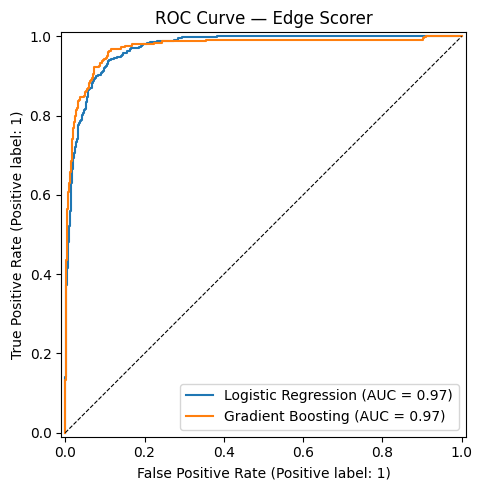

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_gb, name="Gradient Boosting",   ax=ax)
ax.set_title("ROC Curve — Edge Scorer")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.tight_layout()
plt.show()

## Step 7 — Top-$k$ recovery analysis

For each instance with $n$ neighborhoods, we keep the top $m \cdot (n-1)$
edges ranked by the GBM score and measure how many true tree edges are
recovered. A **perfect recovery** means the pruned graph still contains the
full optimal tree.

In [16]:
for mult in [1, 2, 3, 4]:
    results = []
    for inst_id in df["instance_id"].unique():
        sub = df[df["instance_id"] == inst_id].copy()
        n   = sub["n"].iloc[0]
        k   = int((n - 1) * mult)

        X_sub        = scaler.transform(sub[FEATURES].values)
        sub["score"] = gb.predict_proba(X_sub)[:, 1]

        recovered = sub.nlargest(k, "score")["label"].sum()
        results.append(recovered / (n - 1))

    perfect = sum(r == 1.0 for r in results)
    print("top %d*(n-1):  mean recall@k = %.4f  |  perfect = %d/%d (%.1f%%)" % (
        mult, np.mean(results), perfect, len(results),
        100 * perfect / len(results)
    ))

top 1*(n-1):  mean recall@k = 0.9648  |  perfect = 132/159 (83.0%)
top 2*(n-1):  mean recall@k = 0.9957  |  perfect = 153/159 (96.2%)
top 3*(n-1):  mean recall@k = 1.0000  |  perfect = 159/159 (100.0%)
top 4*(n-1):  mean recall@k = 1.0000  |  perfect = 159/159 (100.0%)


## Step 8 — Self-consistency validation (large instances)

For $n > 15$, optimal labels are unavailable (Gurobi becomes intractable).
We instead compare the heuristic cost on the **full complete graph** vs. the
**pruned graph** ($3 \times (n-1)$ edges). A gap close to 0% confirms that
pruning does not degrade solution quality, even on instances far outside the
training distribution.

In [17]:
from heuristic import Heuristic_MSTN_alternating
from random_graph import Create_random_graph
from graph import GeoGraph

def prune_instance(neighborhoods, model, scaler, multiplier=3):
    feat_df = compute_edge_features(neighborhoods)
    X       = scaler.transform(feat_df[FEATURES].values)
    scores  = model.predict_proba(X)[:, 1]
    k       = multiplier * (len(neighborhoods) - 1)
    top_idx = np.argsort(scores)[::-1][:k]
    return [(int(feat_df.iloc[idx]["_i"]), int(feat_df.iloc[idx]["_j"]))
            for idx in top_idx]

results_large = []
for n_test in [20, 30, 50, 100]:
    for seed in range(10):
        G = Create_random_graph(
            n=n_test, m=0, shape="square", integer_size=True,
            size_min=2, size_max=8, grid_size=500
        )
        G.Complete_graph()

        _, _, cost_full, _, _ = Heuristic_MSTN_alternating(G)

        pruned_edges = prune_instance(G.neighborhoods, gb, scaler, multiplier=3)
        G_pruned = GeoGraph(G.neighborhoods)
        G_pruned.edges = pruned_edges  # ← direct assignment, no add_edge

        _, _, cost_pruned, _, _ = Heuristic_MSTN_alternating(G_pruned)

        gap = 100 * (cost_pruned - cost_full) / cost_full
        results_large.append({"n": n_test, "seed": seed,
                               "cost_full": cost_full,
                               "cost_pruned": cost_pruned, "gap_pct": gap})
        print(f"n={n_test:3d} seed={seed}  full={cost_full:.3f}  "
              f"pruned={cost_pruned:.3f}  gap={gap:+.4f}%")

res_df = pd.DataFrame(results_large)
print("\nMean gap by n:")
print(res_df.groupby("n")["gap_pct"].mean().round(3))

n= 20 seed=0  full=1266.704  pruned=1266.704  gap=+0.0000%
n= 20 seed=1  full=1341.279  pruned=1341.279  gap=+0.0000%
n= 20 seed=2  full=1118.490  pruned=1118.490  gap=+0.0000%
n= 20 seed=3  full=1431.402  pruned=1431.402  gap=+0.0000%
n= 20 seed=4  full=1342.066  pruned=1342.066  gap=+0.0000%
n= 20 seed=5  full=1557.817  pruned=1557.817  gap=+0.0000%
n= 20 seed=6  full=1587.893  pruned=1587.893  gap=+0.0000%
n= 20 seed=7  full=1427.638  pruned=1427.638  gap=+0.0000%
n= 20 seed=8  full=1492.732  pruned=1492.732  gap=+0.0000%
n= 20 seed=9  full=1581.512  pruned=1581.512  gap=+0.0000%
n= 30 seed=0  full=1858.272  pruned=1858.272  gap=+0.0000%
n= 30 seed=1  full=1817.255  pruned=1816.763  gap=-0.0271%
n= 30 seed=2  full=1742.572  pruned=1742.572  gap=+0.0000%
n= 30 seed=3  full=1881.255  pruned=1881.255  gap=+0.0000%
n= 30 seed=4  full=1580.468  pruned=1587.536  gap=+0.4472%
n= 30 seed=5  full=1839.193  pruned=1839.193  gap=+0.0000%
n= 30 seed=6  full=1707.035  pruned=1707.035  gap=+0.000

In [18]:
import networkx as nx
import pandas as pd
import time
from tqdm import tqdm
from heuristic import Heuristic_MSTN_alternating
from random_graph import Create_random_graph
from graph import GeoGraph

N_TEST      = 100
N_INSTANCES = 1000
results     = []

for i in tqdm(range(N_INSTANCES), desc="Instances"):
    G = Create_random_graph(
        n=N_TEST, m=0, shape="square", integer_size=True,
        size_min=2, size_max=20, grid_size=500
    )
    G.Complete_graph()

    t0 = time.perf_counter()
    _, _, cost_full, original_cost, k_full = Heuristic_MSTN_alternating(G)
    time_full = time.perf_counter() - t0

    for model_name, model in [("LR", lr), ("GBM", gb)]:
        pruned_edges = prune_instance(G.neighborhoods, model, scaler, multiplier=3)

        H = nx.Graph()
        H.add_nodes_from(range(N_TEST))
        H.add_edges_from(pruned_edges)
        connected = nx.is_connected(H)

        if connected:
            G_pruned       = GeoGraph(G.neighborhoods)
            G_pruned.edges = pruned_edges

            t0 = time.perf_counter()
            _, _, cost_pruned, _, k_pruned = Heuristic_MSTN_alternating(G_pruned)
            time_pruned = time.perf_counter() - t0

            gap         = 100 * (cost_pruned  - cost_full)  / cost_full
            time_ratio  = time_pruned  / (time_full  + 1e-9)
            iter_ratio  = k_pruned     / (k_full     + 1e-9)
        else:
            cost_pruned = gap = time_pruned = k_pruned = None
            time_ratio  = iter_ratio = None

        results.append({
            "instance":         i,
            "model":            model_name,
            # Graph sizes
            "n_edges_full":     len(G.edges),
            "n_edges_pruned":   len(pruned_edges),
            "edge_reduction_pct": 100 * (1 - len(pruned_edges) / len(G.edges)),
            # Connectivity
            "connected":        connected,
            # Costs
            "cost_centers":     original_cost,   # MST on centers, no optimization
            "cost_full":        cost_full,
            "cost_pruned":      cost_pruned,
            "gap_pct":          gap,
            # Heuristic effort
            "iter_full":        k_full,
            "iter_pruned":      k_pruned,
            "iter_ratio":       iter_ratio,       # < 1 means fewer iterations
            "time_full_s":      time_full,
            "time_pruned_s":    time_pruned,
            "time_ratio":       time_ratio,       # < 1 means faster
        })

res_df = pd.DataFrame(results)
res_df.to_csv("pruning_results_n100.csv", index=False)
print(f"Saved {len(res_df)} rows → pruning_results_n100.csv")

print("\n── Connectivity ───────────────────────────────────────")
print(res_df.groupby("model")["connected"]
      .agg(lambda x: f"{x.sum()}/{len(x)}").to_string())

valid = res_df[res_df["connected"]]
print("\n── Cost & gap ─────────────────────────────────────────")
print(valid.groupby("model")["gap_pct"]
      .agg(mean="mean", std="std", min="min", max="max")
      .round(3).to_string())

print("\n── Iteration reduction ────────────────────────────────")
print(valid.groupby("model")["iter_ratio"]
      .agg(mean="mean", min="min", max="max")
      .round(3).to_string())

print("\n── Time reduction ─────────────────────────────────────")
print(valid.groupby("model")["time_ratio"]
      .agg(mean="mean", min="min", max="max")
      .round(3).to_string())

Instances:   1%|▏                            | 6/1000 [00:40<1:51:32,  6.73s/it]


KeyboardInterrupt: 

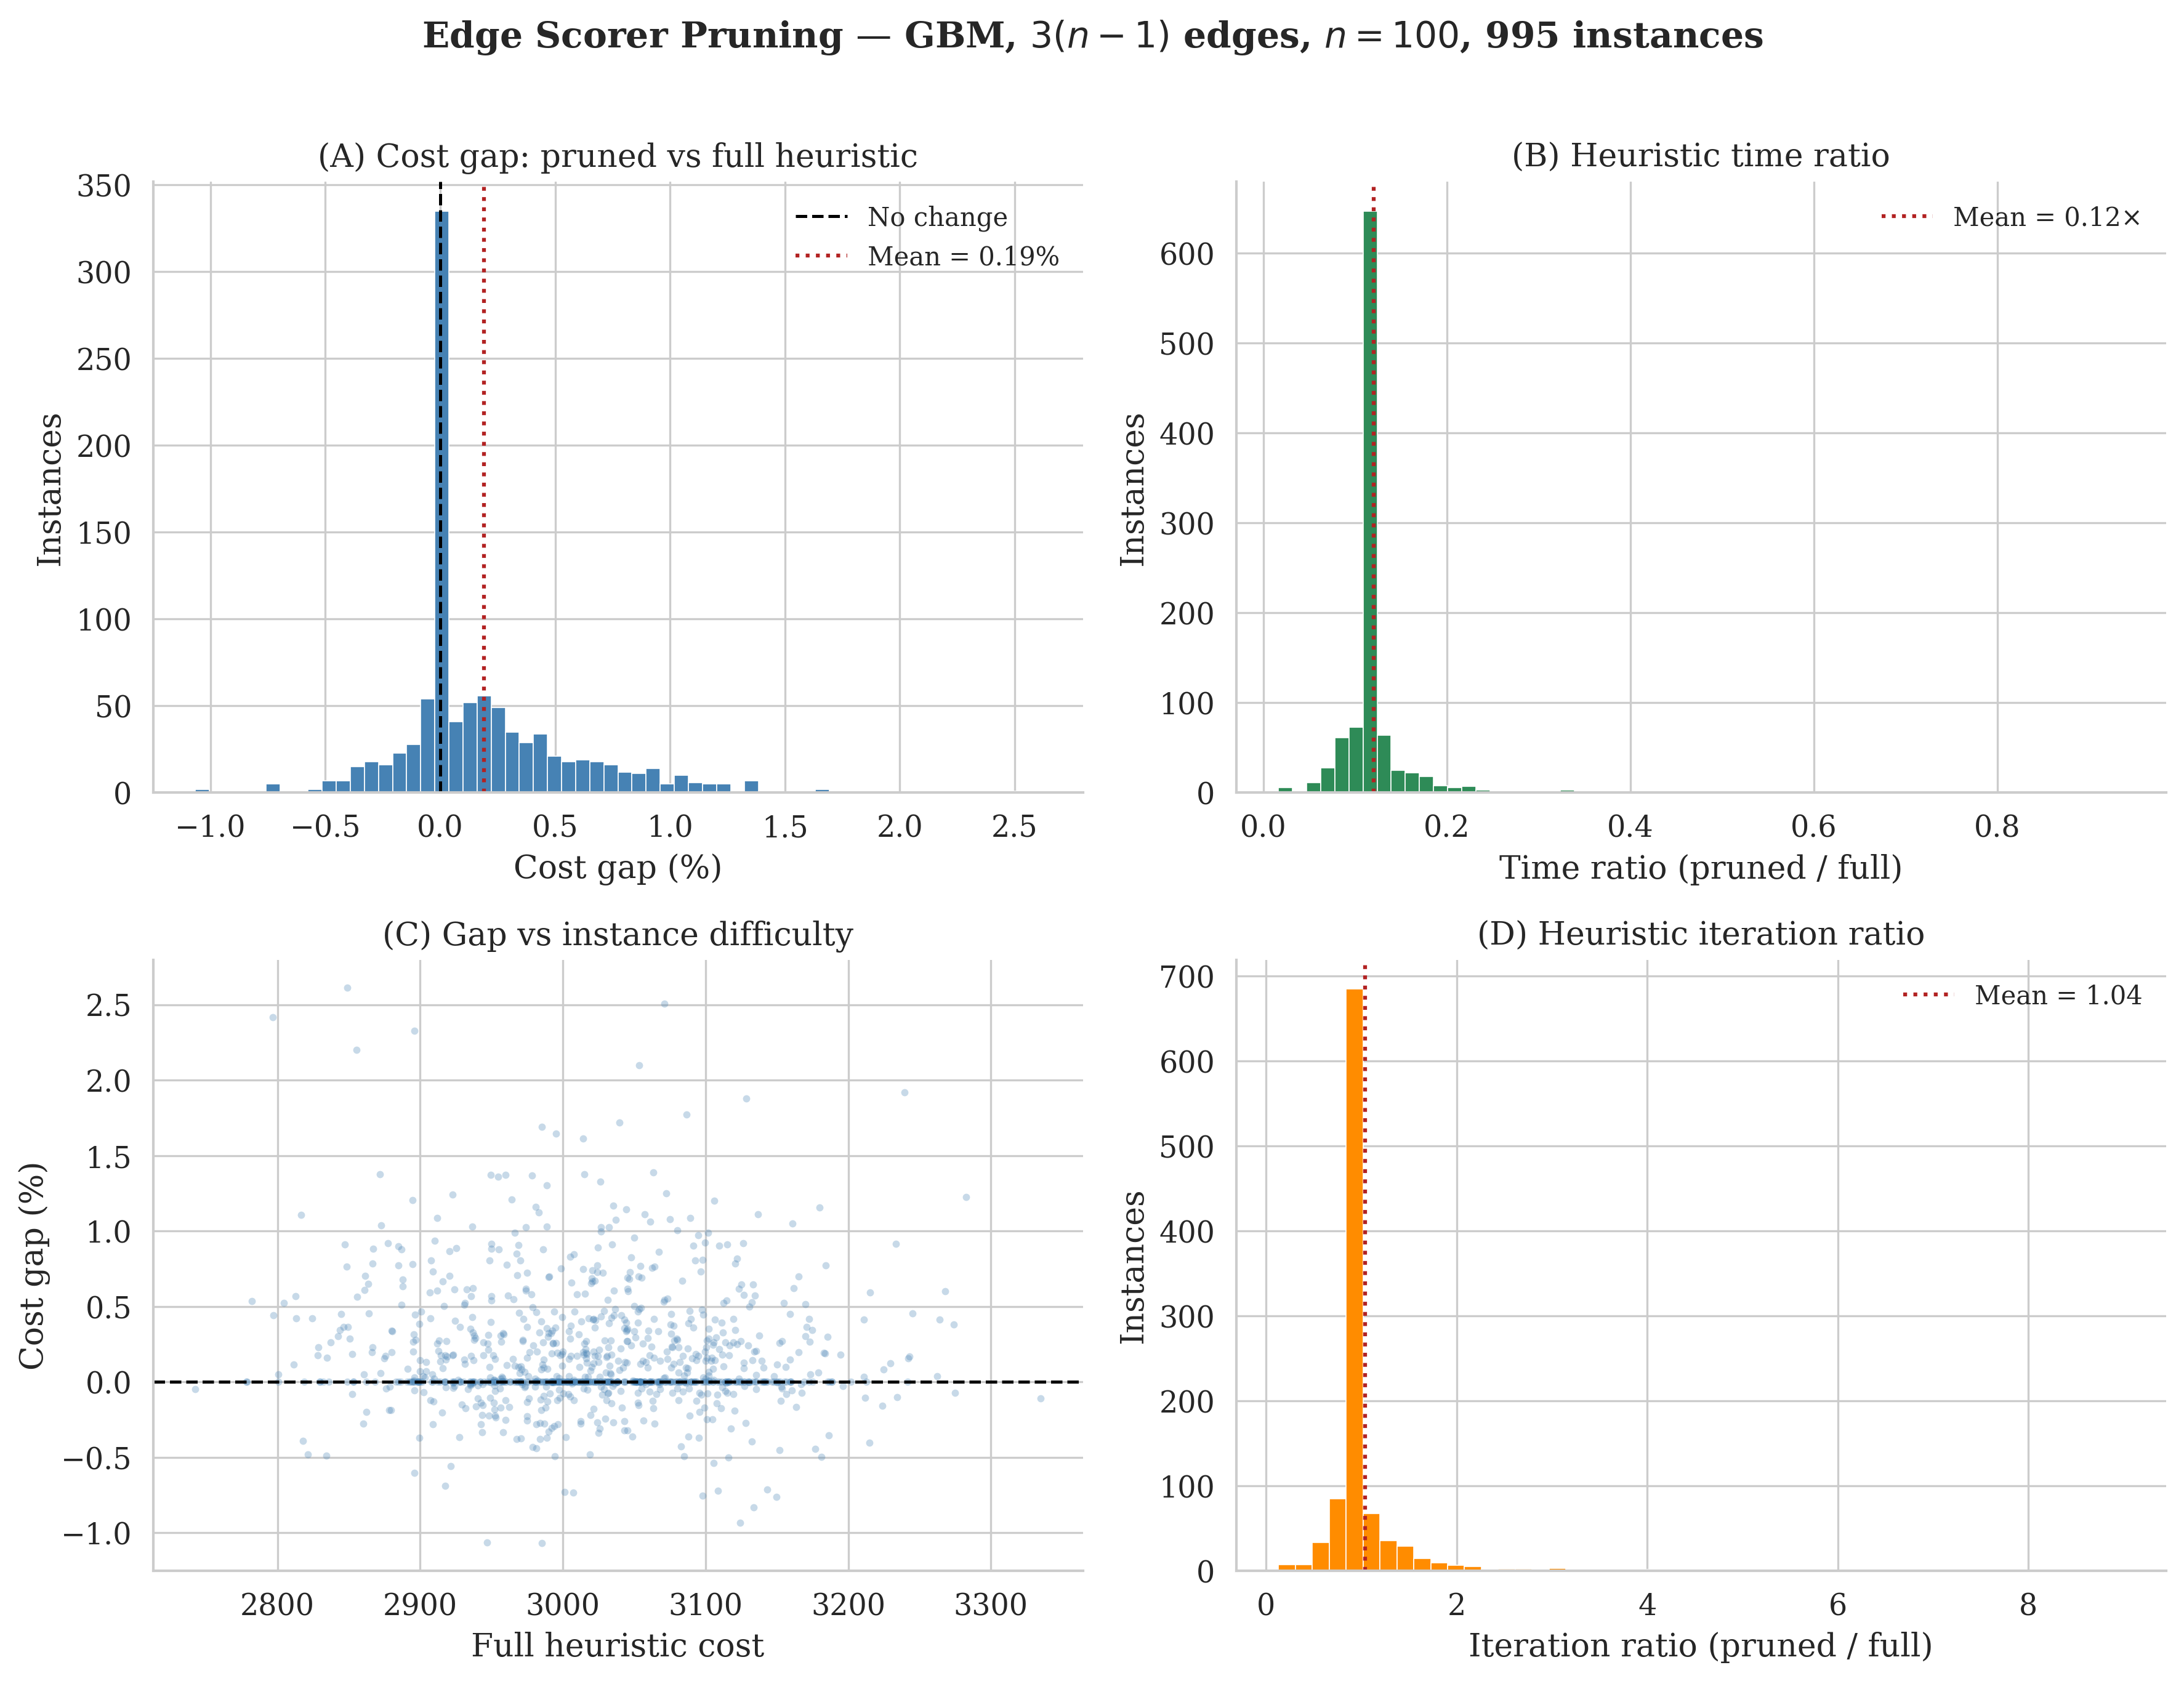

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams.update({
    "font.family":        "serif",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         300,
})

res_df = pd.read_csv("./pruning_results_n100.csv")
gbm = res_df[(res_df["model"] == "GBM") & (res_df["connected"] == True)].copy()

# ── Figure: 2×2 layout ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Edge Scorer Pruning — GBM, $3(n-1)$ edges, $n=100$, 995 instances",
             fontsize=14, fontweight="bold", y=1.01)

# ── (A) Gap distribution ──────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(gbm["gap_pct"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(0,                      color="black",      linestyle="--", linewidth=1.2, label="No change")
ax.axvline(gbm["gap_pct"].mean(),  color="firebrick",  linestyle=":",  linewidth=1.5,
           label=f"Mean = {gbm['gap_pct'].mean():.2f}%")
ax.set_xlabel("Cost gap (%)")
ax.set_ylabel("Instances")
ax.set_title("(A) Cost gap: pruned vs full heuristic")
ax.legend(frameon=False, fontsize=10)

# ── (B) Time ratio distribution ───────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(gbm["time_ratio"], bins=60, color="seagreen", edgecolor="white", linewidth=0.4)
ax.axvline(gbm["time_ratio"].mean(), color="firebrick", linestyle=":", linewidth=1.5,
           label=f"Mean = {gbm['time_ratio'].mean():.2f}×")
ax.set_xlabel("Time ratio (pruned / full)")
ax.set_ylabel("Instances")
ax.set_title("(B) Heuristic time ratio")
ax.legend(frameon=False, fontsize=10)

# ── (C) Gap vs full cost scatter ──────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(gbm["cost_full"], gbm["gap_pct"],
           alpha=0.3, s=8, color="steelblue", linewidths=0)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Full heuristic cost")
ax.set_ylabel("Cost gap (%)")
ax.set_title("(C) Gap vs instance difficulty")

# ── (D) Iteration ratio distribution ─────────────────────────────────────────
ax = axes[1, 1]
ax.hist(gbm["iter_ratio"], bins=50, color="darkorange", edgecolor="white", linewidth=0.4)
ax.axvline(gbm["iter_ratio"].mean(), color="firebrick", linestyle=":", linewidth=1.5,
           label=f"Mean = {gbm['iter_ratio'].mean():.2f}")
ax.set_xlabel("Iteration ratio (pruned / full)")
ax.set_ylabel("Instances")
ax.set_title("(D) Heuristic iteration ratio")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

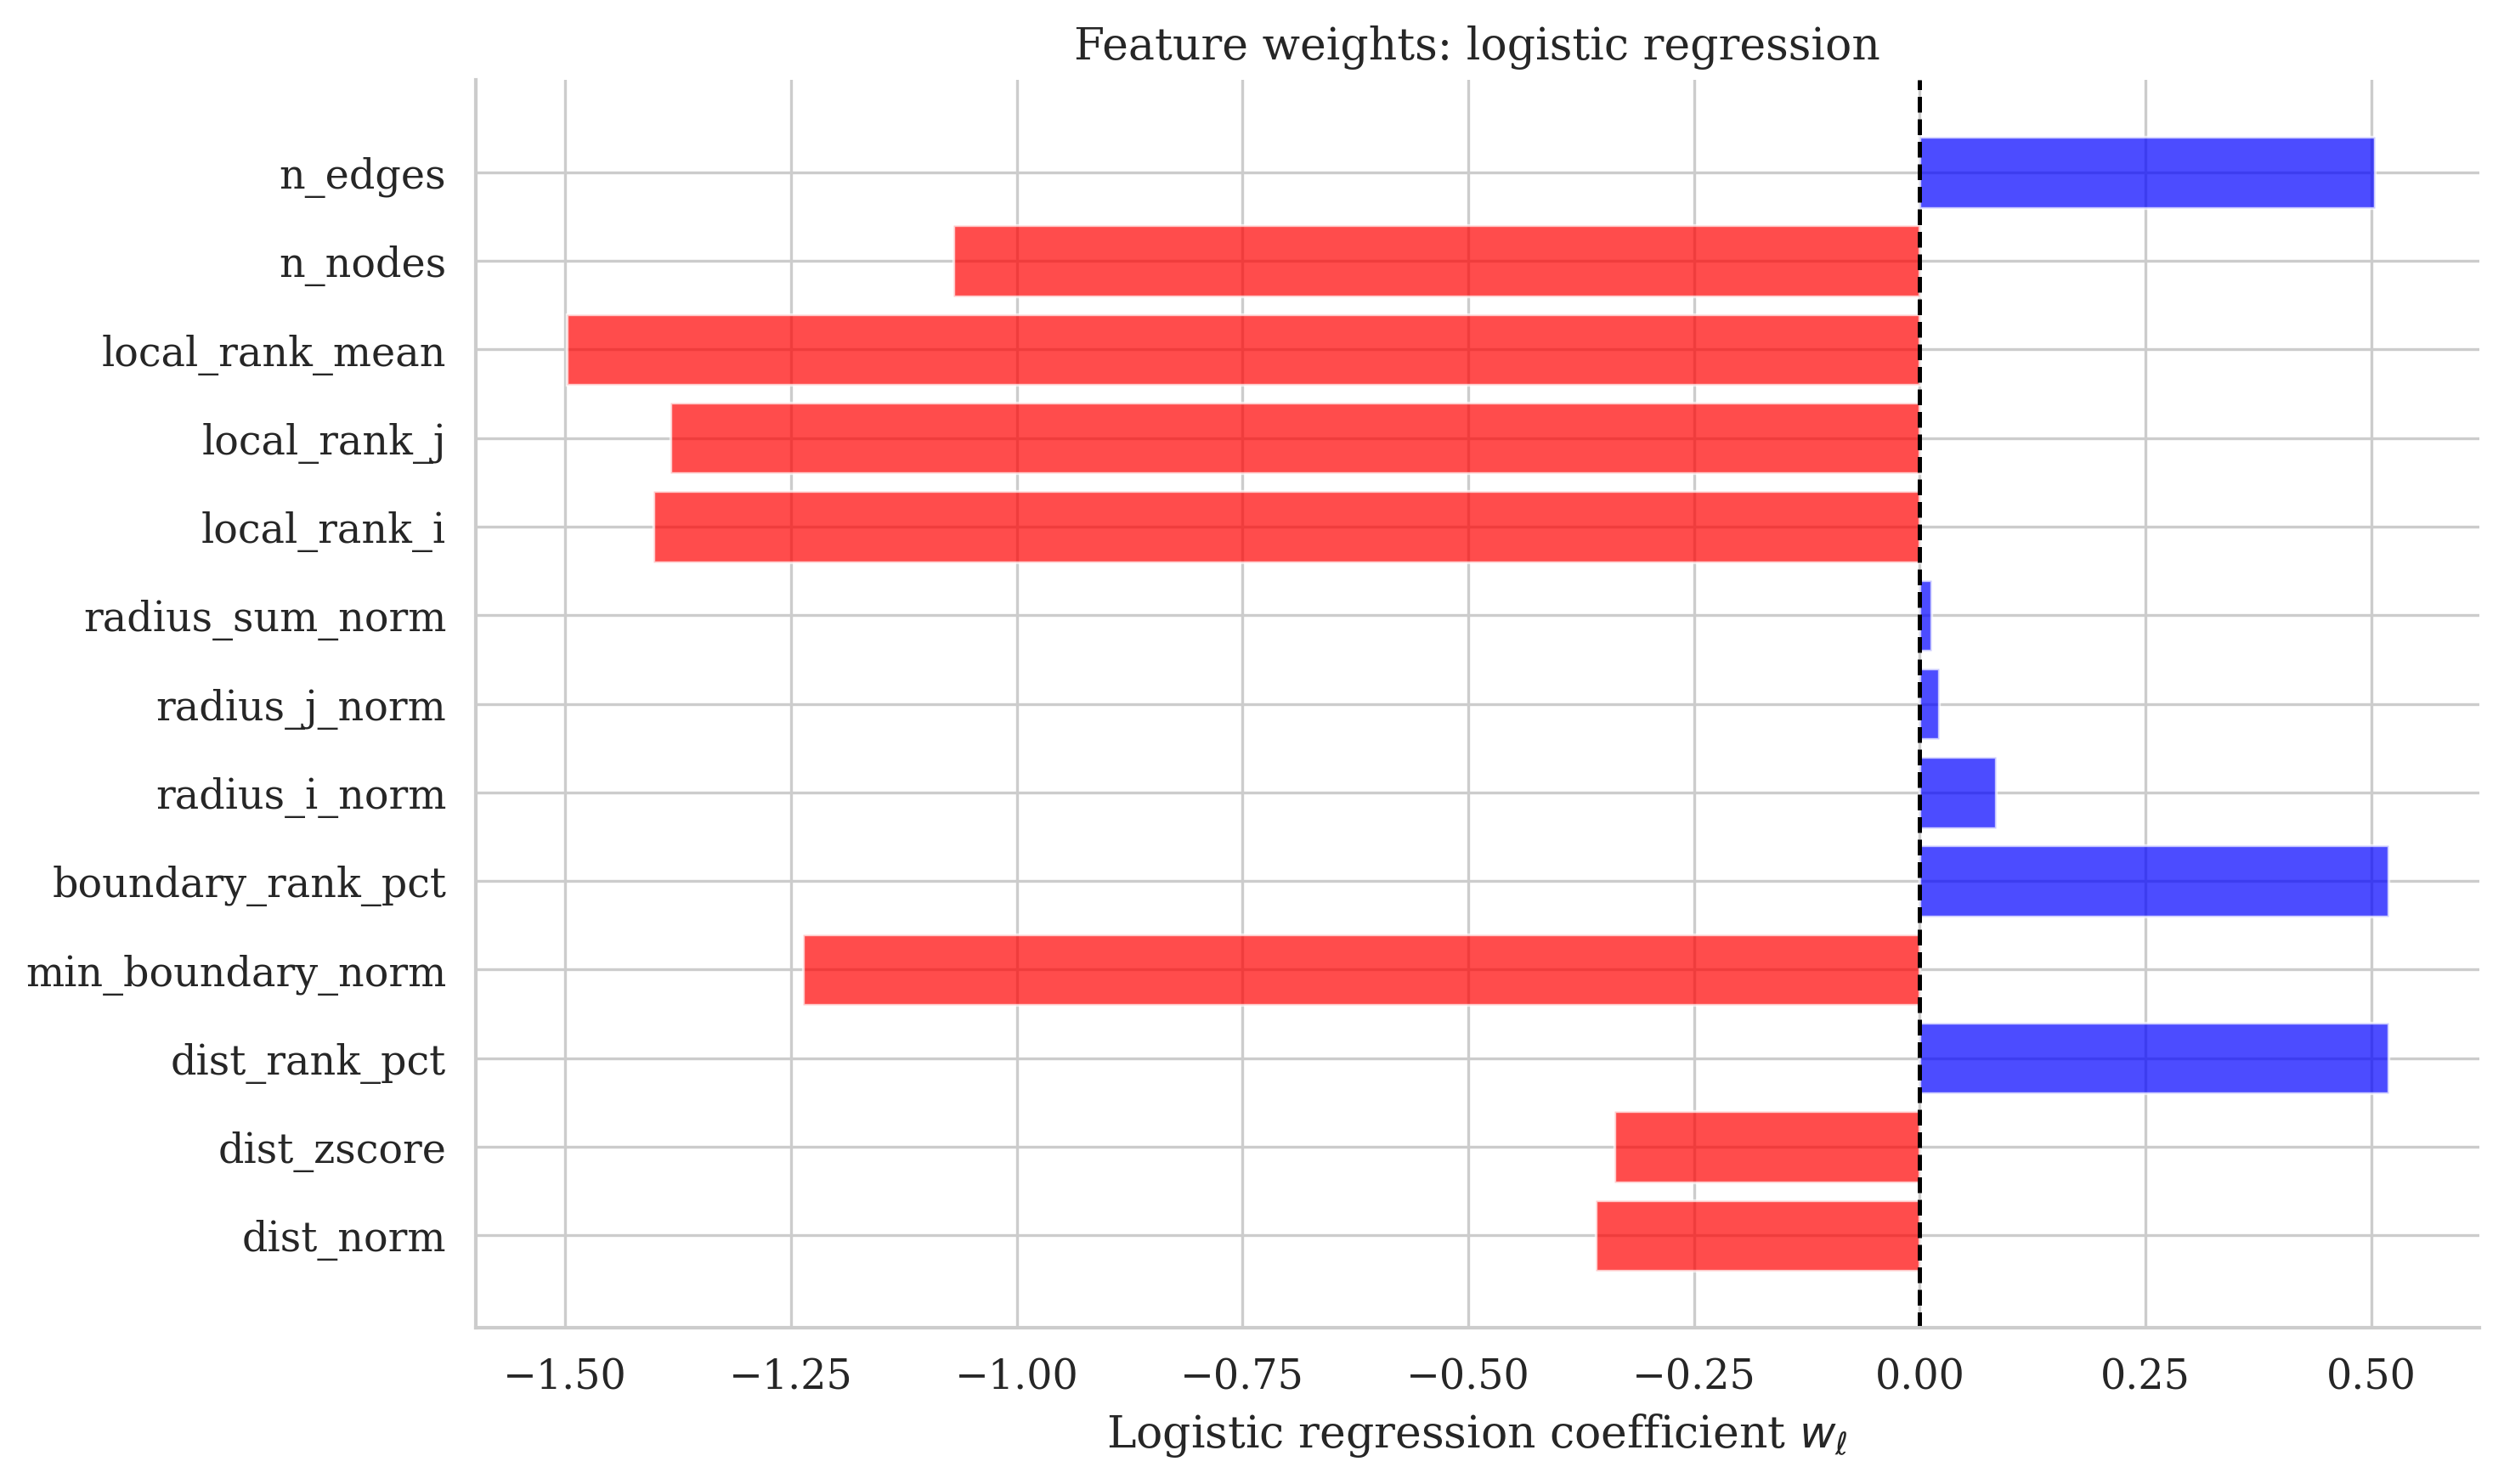

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get LR feature importances (coefficients)
coefs = lr.coef_[0]
feature_names = FEATURES

plt.figure(figsize=(10, 6))
colors = ["red" if c < 0 else "blue" for c in coefs]
plt.barh(feature_names, coefs, color=colors, alpha=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=1.2)
plt.xlabel("Logistic regression coefficient $w_\\ell$")
plt.title("Feature weights: logistic regression")
plt.tight_layout()
plt.savefig("./lr_weights.png", dpi=300, bbox_inches="tight")
plt.show()